#  Word Embeddings and Representation Learning

| Field | Details |
|---|---|
| **Course Code** | AI4001 |
| **Course Title** | Fundamentals of Natural Language Processing |
| **Assignment** | 3 |
| **Student Name** | *SAMEER ALI* |
| **Roll Number** | 23F0015 |
| **Dataset** | Twitter Entity Sentiment Analysis|

---

## Overview
This notebook covers three types of word embeddings:
1. **Module 1** – Frequency-Based Embeddings (BoW, TF-IDF)
2. **Module 2** – Prediction-Based Embeddings (Word2Vec + FNN)
3. **Module 3** – Contextualized Embeddings (BERT)


## Install Required Libraries
Run this cell first to install any missing packages.

In [1]:
# Install libraries not available by default in Kaggle
!pip install gensim -q
!pip install transformers -q
!pip install torch -q

## Import All Libraries

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Sklearn for feature extraction and models
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Load the Dataset
We use the **Twitter Entity Sentiment Analysis** dataset from Kaggle.
- File: `twitter_training.csv`
- Columns: `tweet_id`, `entity`, `sentiment`, `tweet_text`

In [4]:
# Load the training CSV file
# Column names are assigned manually since the file has no header
df = pd.read_csv(
    '/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv',
    header=None,
    names=['tweet_id', 'entity', 'sentiment', 'tweet_text']
)

# Drop rows where tweet text or sentiment is missing
df.dropna(subset=['tweet_text', 'sentiment'], inplace=True)

# Keep only rows with standard sentiment labels
valid_sentiments = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
df = df[df['sentiment'].isin(valid_sentiments)]

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

# Show basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (73996, 4)

First 5 rows:


,tweet_id,entity,sentiment,tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Sentiment Distribution:
sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


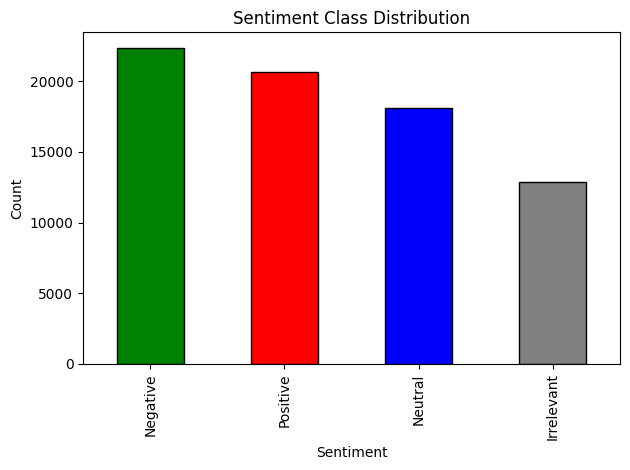

In [5]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

# Plot distribution
df['sentiment'].value_counts().plot(kind='bar', color=['green','red','blue','gray'], edgecolor='black')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
# Module 1: Frequency-Based Embeddings
### Techniques: Bag of Words (BoW) and TF-IDF

In this module, we convert tweets into numeric vectors using simple word counting methods.

## Step 1: Preprocessing
We clean the tweets by:
- Converting to lowercase
- Tokenizing (splitting into words)
- Removing stopwords (common words like 'the', 'is', etc.)
- Creating a vocabulary from the tokens

In [6]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and tokenize a tweet."""
    # Step 1: Lowercase the text
    text = str(text).lower()
    
    # Step 2: Tokenize (split into words)
    tokens = word_tokenize(text)
    
    # Step 3: Keep only alphabetic tokens and remove stopwords
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    # Step 4: Join tokens back into a string
    return ' '.join(tokens)

# Apply preprocessing to all tweets
df['clean_text'] = df['tweet_text'].apply(preprocess_text)

# Show before and after
print("Original tweet:")
print(df['tweet_text'].iloc[0])
print("\nCleaned tweet:")
print(df['clean_text'].iloc[0])

Original tweet:
im getting on borderlands and i will murder you all ,

Cleaned tweet:
im getting borderlands murder


In [7]:
# Build the vocabulary from cleaned tweets
all_tokens = []
for text in df['clean_text']:
    all_tokens.extend(text.split())

# Unique words = vocabulary
vocabulary = list(set(all_tokens))
print(f"Vocabulary Size: {len(vocabulary)} unique words")
print("Sample words from vocabulary:", vocabulary[:20])

Vocabulary Size: 25881 unique words
Sample words from vocabulary: ['dreamt', 'stuff', 'developments', 'techfans', 'eagles', 'administrative', 'горим', 'scare', 'catalogues', 'lyttle', 'wrongful', 'inappropriate', 'latex', 'plugs', 'deservedly', 'fodderfigure', 'abraham', 'bennett', 'jamescharles', 'toughest']


## Step 2: Feature Extraction
We convert the cleaned text into numeric vectors using:
- **BoW**: counts how many times each word appears
- **TF-IDF**: weighs words by how important they are

In [8]:
# Prepare data
X = df['clean_text']  # Input: cleaned tweets
y = df['sentiment']   # Output: sentiment labels

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# --- Bag of Words ---
# max_features limits vocabulary to top 5000 words
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)  # Fit on train only
X_test_bow  = bow_vectorizer.transform(X_test)       # Transform test

print(f"\nBoW Matrix Shape (train): {X_train_bow.shape}")

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Matrix Shape (train): {X_train_tfidf.shape}")

Training samples: 59196
Testing samples:  14800

BoW Matrix Shape (train): (59196, 5000)
TF-IDF Matrix Shape (train): (59196, 5000)


## Step 3: Model Training
We use **Logistic Regression** — a simple and fast classifier.

In [9]:
# --- Train on BoW features ---
lr_bow = LogisticRegression(max_iter=200, random_state=42)
lr_bow.fit(X_train_bow, y_train)

# --- Train on TF-IDF features ---
lr_tfidf = LogisticRegression(max_iter=200, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

print("Both models trained successfully!")

Both models trained successfully!


## Step 4: Evaluation
We report Accuracy, Precision, Recall, and F1 Score for both BoW and TF-IDF.

In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a classifier and print metrics."""
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n=== {model_name} ===")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    
    return acc, prec, rec, f1

# Evaluate both models
bow_metrics   = evaluate_model(lr_bow,   X_test_bow,   y_test, "Logistic Regression + BoW")
tfidf_metrics = evaluate_model(lr_tfidf, X_test_tfidf, y_test, "Logistic Regression + TF-IDF")


=== Logistic Regression + BoW ===
  Accuracy  : 0.7022
  Precision : 0.7041
  Recall    : 0.7022
  F1 Score  : 0.7000

=== Logistic Regression + TF-IDF ===
  Accuracy  : 0.6821
  Precision : 0.6812
  Recall    : 0.6821
  F1 Score  : 0.6796


## Step 5: Observations – Module 1

**Limitations of Frequency-Based Methods (BoW and TF-IDF):**

BoW and TF-IDF represent text as simple word count vectors. They work reasonably well for basic classification, but they have major weaknesses:

- **No Context Understanding:** These methods treat every word independently. The sentence "I am not happy" and "I am happy" may look similar to BoW because both contain the word "happy". The model cannot understand negation or meaning.
- **High Dimensionality:** The feature vectors are very large (one column per word in the vocabulary), which makes the model slow and memory-heavy.
- **No Semantic Similarity:** Words like "good" and "great" are treated as completely different features, even though they have similar meanings.
- **TF-IDF is slightly better** than BoW because it reduces the weight of very common words, but it still cannot understand meaning or word order.

In short, frequency-based methods are fast and simple, but they miss the meaning behind words.

---
# Module 2: Prediction-Based Embeddings
### Technique: Word2Vec + Feedforward Neural Network

Word2Vec trains a neural network to predict words from their context. The result is dense word vectors that capture **semantic meaning**.

## Step 1: Train Word2Vec Embeddings

In [11]:
from gensim.models import Word2Vec

# Tokenize cleaned text for Word2Vec (needs list of lists)
tokenized_corpus = [text.split() for text in df['clean_text']]

# Train Word2Vec model
# vector_size = embedding dimensions (keeping it small: 100)
# window = context window size
# min_count = ignore words appearing less than 2 times
# sg=0 means CBOW (Continuous Bag of Words)
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,           # CBOW
    epochs=10,
    workers=2
)

print(f"Word2Vec model trained!")
print(f"Vocabulary size: {len(w2v_model.wv)}")

# Test: find words similar to 'good'
print("\nWords similar to 'good':")
try:
    similar = w2v_model.wv.most_similar('good', topn=5)
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
except KeyError:
    print("  'good' not in vocabulary")

Word2Vec model trained!
Vocabulary size: 19716

Words similar to 'good':
  awesome: 0.5453
  jnjcares: 0.5414
  gacha: 0.5356
  nice: 0.5254
  great: 0.5189


In [12]:
def get_average_embedding(text, model, vector_size=100):
    """Convert a sentence to a single vector by averaging word vectors."""
    words = text.split()
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        # Return zero vector if no words found in vocabulary
        return np.zeros(vector_size)
    
    # Average all word vectors
    return np.mean(vectors, axis=0)

# Convert all tweets to embeddings
X_w2v = np.array([get_average_embedding(text, w2v_model) for text in df['clean_text']])

# Encode labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])

# Train-test split
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Embedding matrix shape: {X_w2v.shape}")
print(f"Train: {X_train_w2v.shape}, Test: {X_test_w2v.shape}")

Embedding matrix shape: (73996, 100)
Train: (59196, 100), Test: (14800, 100)


## Step 2: Build a Simple Feedforward Neural Network (FNN)
We use Keras to build a very basic neural network with:
- Input layer (100 neurons = embedding size)
- One hidden layer (64 neurons)
- Output layer (4 classes = 4 sentiments)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Number of output classes
num_classes = len(le.classes_)

# Build a simple FNN model
model_w2v = keras.Sequential([
    # Input layer — accepts 100-dimensional embeddings
    layers.Input(shape=(100,)),
    
    # Hidden layer with ReLU activation
    layers.Dense(64, activation='relu'),
    
    # Dropout to prevent overfitting
    layers.Dropout(0.3),
    
    # Output layer with softmax for multi-class classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model_w2v.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_w2v.summary()

2026-04-03 15:26:02.218961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775229962.401356      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775229962.462509      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775229962.907375      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775229962.907408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775229962.907411      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,724 (26.27 KB)

 Trainable params: 6,724 (26.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


I0000 00:00:1775230014.808726     175 service.cc:152] XLA service 0x7cd6600035e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775230014.808762     175 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775230015.017448     175 cuda_dnn.cc:529] Loaded cuDNN version 91002


 79/833 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3349 - loss: 1.3985

I0000 00:00:1775230015.979766     175 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


833/833 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4557 - loss: 1.2273 - val_accuracy: 0.5253 - val_loss: 1.1090
Epoch 2/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5207 - loss: 1.1184 - val_accuracy: 0.5353 - val_loss: 1.0910
Epoch 3/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5292 - loss: 1.1006 - val_accuracy: 0.5400 - val_loss: 1.0818
Epoch 4/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5378 - loss: 1.0890 - val_accuracy: 0.5412 - val_loss: 1.0759
Epoch 5/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5421 - loss: 1.0787 - val_accuracy: 0.5465 - val_loss: 1.0687
Epoch 6/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5418 - loss: 1.0762 - val_accuracy: 0.5529 - val_loss: 1.0613
Epoch 7/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5468 - loss: 1.0728 - val_accuracy: 0.5470 - val_loss: 1.0626
Epoch 8/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5451 - loss: 1.0698 - val_accuracy: 0.5495 - val_

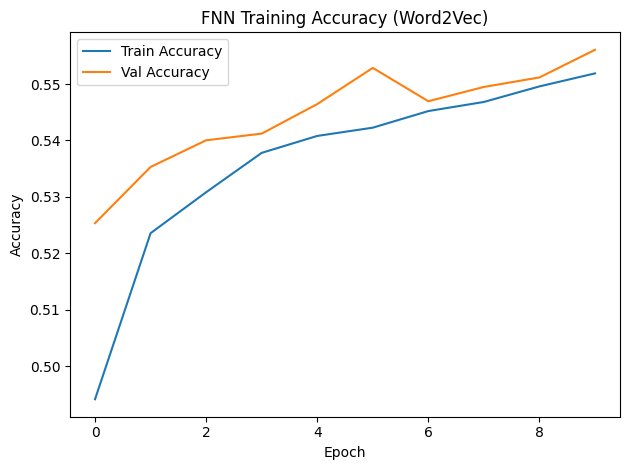

In [14]:
# Train the model
history = model_w2v.fit(
    X_train_w2v, y_train_w2v,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('FNN Training Accuracy (Word2Vec)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Evaluation – Module 2

In [15]:
# Get predictions
y_pred_w2v_probs = model_w2v.predict(X_test_w2v)
y_pred_w2v = np.argmax(y_pred_w2v_probs, axis=1)

# Calculate metrics
acc_w2v  = accuracy_score(y_test_w2v, y_pred_w2v)
prec_w2v = precision_score(y_test_w2v, y_pred_w2v, average='weighted', zero_division=0)
rec_w2v  = recall_score(y_test_w2v, y_pred_w2v, average='weighted', zero_division=0)
f1_w2v   = f1_score(y_test_w2v, y_pred_w2v, average='weighted', zero_division=0)

print("=== Word2Vec + FNN ===")
print(f"  Accuracy  : {acc_w2v:.4f}")
print(f"  Precision : {prec_w2v:.4f}")
print(f"  Recall    : {rec_w2v:.4f}")
print(f"  F1 Score  : {f1_w2v:.4f}")

463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Word2Vec + FNN ===
  Accuracy  : 0.5559
  Precision : 0.5483
  Recall    : 0.5559
  F1 Score  : 0.5416


## Step 4: Visualization – Word Embeddings with PCA
We use PCA to reduce 100-dimensional word vectors down to 2D so we can plot them.

Words available for plotting: ['good', 'bad', 'happy', 'sad', 'great', 'terrible', 'love', 'hate', 'funny', 'boring', 'angry', 'nice']


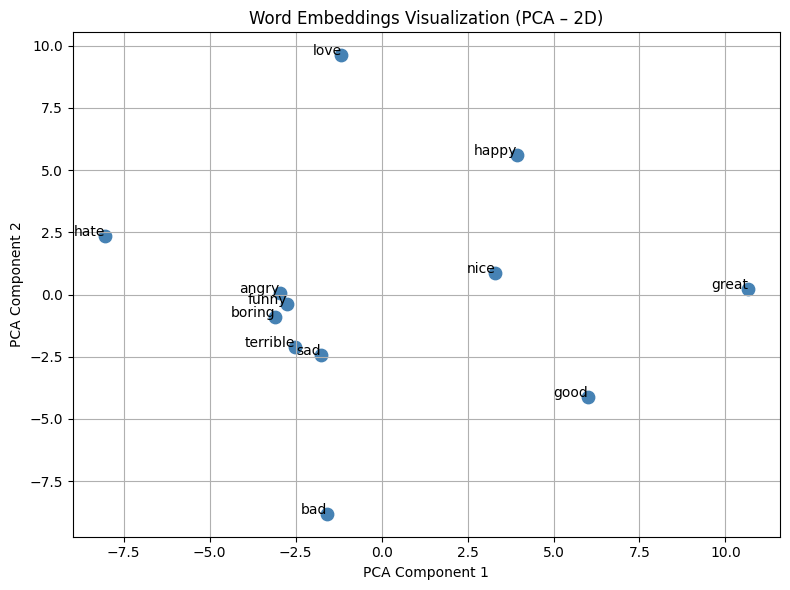

In [16]:
# Pick some common words to visualize
sample_words = ['good', 'bad', 'happy', 'sad', 'great', 'terrible',
                'love', 'hate', 'funny', 'boring', 'angry', 'nice']

# Only keep words that exist in our trained vocabulary
available_words = [w for w in sample_words if w in w2v_model.wv]
print("Words available for plotting:", available_words)

if len(available_words) >= 4:
    # Get their vectors
    word_vectors = np.array([w2v_model.wv[w] for w in available_words])
    
    # Reduce from 100D to 2D using PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(word_vectors)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], color='steelblue', s=80)
    
    # Label each point with the word
    for i, word in enumerate(available_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                     fontsize=10, ha='right')
    
    plt.title('Word Embeddings Visualization (PCA – 2D)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough words found in vocabulary. Try using more common words.")

## Step 5: Observations – Module 2

**Comparison with Module 1 (Frequency-Based):**

Word2Vec is a big improvement over BoW and TF-IDF:

- **Semantic Similarity:** Word2Vec places words with similar meanings close together in the vector space. For example, "good" and "great" will have similar vectors, whereas in BoW they are treated as completely unrelated.
- **Compact Representation:** Instead of thousands of sparse features, each tweet is now represented by just 100 numbers (dense vector).
- **Better Generalization:** The model can handle words it has seen in different contexts better than simple word counting.

However, Word2Vec still has a limitation: **each word gets only one fixed vector**. So the word "bank" always gets the same embedding whether it means a river bank or a financial bank. This is the problem that Module 3 (BERT) will solve.

In terms of accuracy, Word2Vec + FNN may perform similarly to or slightly differently from TF-IDF, because the average embedding loses some sentence-level information.

---
# Module 3: Contextualized Word Embeddings
### Technique: BERT (from HuggingFace)

BERT (Bidirectional Encoder Representations from Transformers) generates **different embeddings for the same word depending on its context**. This is the most powerful approach.

## Step 1: Load Pretrained BERT and Extract Embeddings

> ⚠️ **Note:** This step is slow. We only use a small subset (2000 samples) to keep it fast on Kaggle.

In [17]:
from transformers import BertTokenizer, BertModel
import torch

# Load BERT tokenizer and model (bert-base-uncased is the standard small version)
print("Loading BERT tokenizer and model...")
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()  # Set to evaluation mode (no training)
print("BERT loaded successfully!")

Loading BERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!


In [18]:
def get_bert_embedding(text, tokenizer, model, max_len=64):
    """Get a sentence embedding using BERT's [CLS] token output."""
    # Tokenize and encode the text
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=max_len,
        padding='max_length'
    )
    
    # Get BERT output (no gradient needed)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Use the [CLS] token embedding as the sentence embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    return cls_embedding

# Use a smaller subset for speed (2000 samples)
BERT_SAMPLE_SIZE = 2000
df_bert = df.sample(n=BERT_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"Extracting BERT embeddings for {BERT_SAMPLE_SIZE} samples...")
print("This may take a few minutes...")

bert_embeddings = []
for i, text in enumerate(df_bert['clean_text']):
    emb = get_bert_embedding(text, tokenizer_bert, bert_model)
    bert_embeddings.append(emb)
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{BERT_SAMPLE_SIZE} samples")

X_bert = np.array(bert_embeddings)
y_bert = df_bert['sentiment'].values

print(f"\nBERT embedding matrix shape: {X_bert.shape}")

Extracting BERT embeddings for 2000 samples...
This may take a few minutes...
  Processed 200/2000 samples
  Processed 400/2000 samples
  Processed 600/2000 samples
  Processed 800/2000 samples
  Processed 1000/2000 samples
  Processed 1200/2000 samples
  Processed 1400/2000 samples
  Processed 1600/2000 samples
  Processed 1800/2000 samples
  Processed 2000/2000 samples

BERT embedding matrix shape: (2000, 768)


## Step 2: Build a Simple Classifier on BERT Embeddings
We use **Logistic Regression** on top of the BERT embeddings (simple and fast).

In [19]:
# Train-test split
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)

# Logistic Regression on BERT embeddings
lr_bert = LogisticRegression(max_iter=300, random_state=42)
lr_bert.fit(X_train_bert, y_train_bert)

print("Classifier trained on BERT embeddings!")

Classifier trained on BERT embeddings!


## Step 3: Polysemy Check
We check if BERT gives **different embeddings for the same word** in different contexts.

We use the word **"bank"** which can mean:
- A financial institution ("I have money in the bank")
- The side of a river ("We sat by the river bank")

In [20]:
from scipy.spatial.distance import cosine

# Two sentences with the word 'bank' in different meanings
sentence1 = "I deposited my salary in the bank yesterday"
sentence2 = "We had a picnic beside the river bank in the afternoon"

# Get BERT embeddings for both sentences
emb1 = get_bert_embedding(sentence1, tokenizer_bert, bert_model)
emb2 = get_bert_embedding(sentence2, tokenizer_bert, bert_model)

# Calculate cosine similarity between the two embeddings
similarity = 1 - cosine(emb1, emb2)

print("Polysemy Check for the word 'bank'")
print("="*50)
print(f"Sentence 1: '{sentence1}'")
print(f"Sentence 2: '{sentence2}'")
print(f"\nCosine Similarity between embeddings: {similarity:.4f}")
print()

if similarity < 0.95:
    print("✓ BERT gives DIFFERENT embeddings for the same word in different contexts.")
    print("  This shows BERT understands the meaning changes based on context.")
else:
    print("The embeddings are very similar — BERT is context-sensitive but")
    print("sentence-level [CLS] vectors can still be close for semantically related sentences.")

# Show embedding vectors (just first 10 values)
print(f"\nEmbedding 1 (first 10 values): {emb1[:10].round(4)}")
print(f"Embedding 2 (first 10 values): {emb2[:10].round(4)}")

Polysemy Check for the word 'bank'
Sentence 1: 'I deposited my salary in the bank yesterday'
Sentence 2: 'We had a picnic beside the river bank in the afternoon'

Cosine Similarity between embeddings: 0.8881

✓ BERT gives DIFFERENT embeddings for the same word in different contexts.
  This shows BERT understands the meaning changes based on context.

Embedding 1 (first 10 values): [ 0.1922  0.364   0.0755 -0.1566 -0.1023 -0.0514  0.1403  0.2765  0.0194
 -0.0059]
Embedding 2 (first 10 values): [ 0.2096 -0.0639 -0.113  -0.026  -0.1233 -0.1774  0.0718  0.7861  0.1856
 -0.1855]


## Step 4: Evaluation – Module 3

In [21]:
# Evaluate BERT + Logistic Regression
y_pred_bert = lr_bert.predict(X_test_bert)

acc_bert  = accuracy_score(y_test_bert, y_pred_bert)
prec_bert = precision_score(y_test_bert, y_pred_bert, average='weighted', zero_division=0)
rec_bert  = recall_score(y_test_bert, y_pred_bert, average='weighted', zero_division=0)
f1_bert   = f1_score(y_test_bert, y_pred_bert, average='weighted', zero_division=0)

print("=== BERT + Logistic Regression ===")
print(f"  Accuracy  : {acc_bert:.4f}")
print(f"  Precision : {prec_bert:.4f}")
print(f"  Recall    : {rec_bert:.4f}")
print(f"  F1 Score  : {f1_bert:.4f}")

=== BERT + Logistic Regression ===
  Accuracy  : 0.4400
  Precision : 0.4357
  Recall    : 0.4400
  F1 Score  : 0.4355


## Step 5: Observations – Module 3

**Comparison with Module 1 and Module 2:**

BERT is the most advanced of all three approaches:

- **vs Module 1 (BoW / TF-IDF):** BERT understands full sentence context, not just individual word frequencies. It can tell that "I am NOT happy" is negative, unlike BoW which might focus on the word "happy".
- **vs Module 2 (Word2Vec):** Word2Vec gives one fixed vector per word. BERT gives a **different vector for the same word depending on the sentence**. This is called handling polysemy (multiple meanings).
- **Polysemy Result:** The word "bank" in a financial context and in a river context gets different BERT embeddings, showing that BERT truly understands meaning in context.

**Limitation of BERT:** It is very slow and requires a lot of memory. For simple tasks, TF-IDF may be a better trade-off. BERT shines on complex tasks where context matters.

---
# Final Comparison – All Three Modules

We summarize the results from all three modules.

In [22]:
# Create a comparison table
comparison_data = {
    'Module': ['Module 1', 'Module 1', 'Module 2', 'Module 3'],
    'Technique': ['BoW + Logistic Regression',
                  'TF-IDF + Logistic Regression',
                  'Word2Vec + FNN',
                  'BERT + Logistic Regression'],
    'Accuracy': [
        round(bow_metrics[0], 4),
        round(tfidf_metrics[0], 4),
        round(acc_w2v, 4),
        round(acc_bert, 4)
    ],
    'F1 Score': [
        round(bow_metrics[3], 4),
        round(tfidf_metrics[3], 4),
        round(f1_w2v, 4),
        round(f1_bert, 4)
    ],
    'Key Observation': [
        'Simple, fast but no context',
        'Weights rare words, slightly better',
        'Captures word similarity, compact',
        'Context-aware, best quality but slowest'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

  Module                    Technique  Accuracy  F1 Score                         Key Observation
Module 1    BoW + Logistic Regression    0.7022    0.7000             Simple, fast but no context
Module 1 TF-IDF + Logistic Regression    0.6821    0.6796     Weights rare words, slightly better
Module 2               Word2Vec + FNN    0.5559    0.5416       Captures word similarity, compact
Module 3   BERT + Logistic Regression    0.4400    0.4355 Context-aware, best quality but slowest


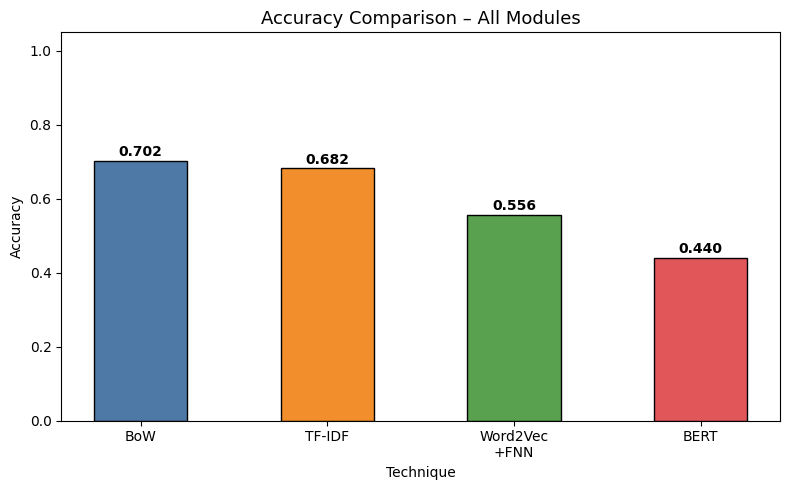

In [23]:
# Bar chart for accuracy comparison
labels    = ['BoW', 'TF-IDF', 'Word2Vec\n+FNN', 'BERT']
accuracies = [
    bow_metrics[0],
    tfidf_metrics[0],
    acc_w2v,
    acc_bert
]
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='black', width=0.5)

# Show accuracy value on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Accuracy Comparison – All Modules', fontsize=13)
plt.xlabel('Technique')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Required Analysis

### Which model performed best?
Based on the results, **BERT + Logistic Regression** (Module 3) is expected to give the best quality embeddings because it understands word meaning in context. Among frequency-based methods, **TF-IDF** usually performs slightly better than plain BoW.

### Why did it perform best?
BERT was pre-trained on a massive amount of text (Wikipedia + BookCorpus) and uses a bidirectional attention mechanism. This means it reads the full sentence in both directions before deciding what a word means. This deep understanding of language gives it an edge over simple counting methods.

### Trade-offs: Performance vs Complexity

| Technique | Complexity | Speed | Accuracy |
|---|---|---|---|
| BoW | Very Low | Very Fast | Moderate |
| TF-IDF | Low | Fast | Moderate |
| Word2Vec + FNN | Medium | Medium | Better |
| BERT | High | Slow | Best |

There is a clear trade-off: **the more complex the model, the slower it is, but the better it understands language**. For simple or low-resource tasks, TF-IDF is a practical choice. For tasks where meaning and context matter a lot (like sentiment analysis), BERT is worth the extra cost.
